# 4. Сверточные нейросети
Реализовать сверточную сеть с архитектурой LeNet-5 для классификации рукописных цифр.

## Использованные библиотеки

In [20]:
import numpy as np
import matplotlib.pyplot as plt

import gzip
import struct
from urllib import request

import time
print("Библиотеки подключены успешно!")

Библиотеки подключены успешно!


Для библиотечной реализации через PyTorch:

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

print("Библиотеки для библиотечной реализации подключены успешно!")

Библиотеки для библиотечной реализации подключены успешно!


## Установка данных и препроцессинг

In [23]:
MNIST_URLS = {
    'train_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_images':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz',
}


def download_file(url, filename):
    request.urlretrieve(url, filename)

download_file(MNIST_URLS['train_images'], 'train-images.gz')
download_file(MNIST_URLS['train_labels'], 'train-labels.gz')
download_file(MNIST_URLS['test_images'],  'test-images.gz')
download_file(MNIST_URLS['test_labels'],  'test-labels.gz')

# Добавить: print(f"Файл {...} сохранен как {...}")

In [24]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))

        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)

        return images

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))

        labels = np.frombuffer(f.read(), dtype=np.uint8)

        return labels

In [25]:
X_train_raw = load_images('train-images.gz')
y_train = load_labels('train-labels.gz')

X_test_raw = load_images('test-images.gz')
y_test = load_labels('test-labels.gz')

print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')

Train: (60000, 28, 28) | Test: (10000, 28, 28)


In [26]:
def preprocessing(images):
    N = images.shape[0]
    # Zero-padding
    padded = np.zeros((N, 32, 32), dtype=np.float32)
    # Нормализация
    padded[:, 2:30, 2:30] = images.astype(np.float32) / 255.0
    # Добавление оси канала
    return padded[:, np.newaxis, :, :]

X_train = preprocessing(X_train_raw)   # (60000, 1, 32, 32)
X_test  = preprocessing(X_test_raw)    # (10000, 1, 32, 32)

In [27]:
print(f'До препроцессинга: train={X_train_raw.shape}, test={X_test_raw.shape}')
print(f'Диапазон: [{X_train_raw.min():.3f}, {X_train_raw.max():.3f}]')

print(f'После препроцессинга: train={X_train.shape}, test={X_test.shape}')
print(f'Диапазон: [{X_train.min():.3f}, {X_train.max():.3f}]')


До препроцессинга: train=(60000, 28, 28), test=(10000, 28, 28)
Диапазон: [0.000, 255.000]
После препроцессинга: train=(60000, 1, 32, 32), test=(10000, 1, 32, 32)
Диапазон: [0.000, 1.000]


## Библиотечная реализация LeNet-5
---
Реализация, близкая к оригинальному описанию LeNet-5 (по слоям).

In [ ]:
# Параметры

EPOCHS = 10
BATCH_SIZE = 128
LR = 0.01

In [29]:
class TorchLeNet5(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
      nn.Conv2d(1, 6, 5),
      nn.Tanh(),
      nn.AvgPool2d(2, 2),
      nn.Conv2d(6, 16, 5),
      nn.Tanh(),
      nn.AvgPool2d(2, 2),
      nn.Conv2d(16, 120, 5),
      nn.Tanh(),
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(120, 84),
      nn.Tanh(),
      nn.Linear(84, 10),
    )

  def forward(self, x):
    return self.classifier(self.features(x))

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train.astype(np.int64))
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test.astype(np.int64))

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
    )
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
    )

torch_model = TorchLeNet5().to(device)
criterion = nn.CrossEntropyLoss()
torch_opt = optim.SGD(torch_model.parameters(), lr=LR, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(torch_opt, milestones=[7, 9], gamma=0.1)


In [31]:
n_params = sum(p.numel() for p in torch_model.parameters())

print(f'Библиотечная: {EPOCHS} эпох | батч {BATCH_SIZE}')
print('-' * 50)

hist_t = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    torch_model.train()

    epoch_loss = 0
    epoch_corr = 0
    epoch_n = 0

    epoch_time = time.time()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        torch_opt.zero_grad()

        # прямой проход
        logits = torch_model(images)
        loss = criterion(logits, labels)

        # обратный проход, оптимизация
        loss.backward()
        torch_opt.step()

        epoch_loss += loss.item() * len(labels)
        epoch_corr += (logits.argmax(1) == labels).sum().item()
        epoch_n  += len(labels)
    scheduler.step()

    # валидация на тестовой выборке после каждой эпохи
    torch_model.eval()
    te_loss = 0
    te_corr = 0
    te_n = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = torch_model(images)
            te_loss += criterion(logits, labels).item() * len(labels)
            te_corr += (logits.argmax(1) == labels).sum().item()
            te_n += len(labels)

    hist_t['train_loss'].append(epoch_loss / epoch_n)
    hist_t['train_acc'].append(epoch_corr / epoch_n)
    hist_t['test_loss'].append(te_loss / te_n)
    hist_t['test_acc'].append(te_corr / te_n)

    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'Train Loss: {epoch_loss/epoch_n:.4f} Accuracy: {epoch_corr/epoch_n:.4f} | '
          f'Test Loss: {te_loss/te_n:.4f} Accuracy: {te_corr/te_n:.4f} | '
          f'Time: {time.time()-epoch_time:.2f}s')

torch_time = time.time() - start_time
print('-' * 50)
print(f'Result | Test accuracy: {hist_t["test_acc"][-1]:.4f} | Time: {torch_time:.1f}s')

Библиотечная: 10 эпох | батч 128
--------------------------------------------------
Epoch  1/10 | Train Loss: 0.8482 Accuracy: 0.7509 | Test Loss: 0.2664 Accuracy: 0.9226 | Time: 1.9s
Epoch  2/10 | Train Loss: 0.2035 Accuracy: 0.9394 | Test Loss: 0.1316 Accuracy: 0.9603 | Time: 1.7s
Epoch  3/10 | Train Loss: 0.1226 Accuracy: 0.9639 | Test Loss: 0.0870 Accuracy: 0.9739 | Time: 1.7s
Epoch  4/10 | Train Loss: 0.0879 Accuracy: 0.9736 | Test Loss: 0.0752 Accuracy: 0.9778 | Time: 1.9s
Epoch  5/10 | Train Loss: 0.0699 Accuracy: 0.9788 | Test Loss: 0.0610 Accuracy: 0.9799 | Time: 2.1s
Epoch  6/10 | Train Loss: 0.0588 Accuracy: 0.9822 | Test Loss: 0.0525 Accuracy: 0.9839 | Time: 1.7s
Epoch  7/10 | Train Loss: 0.0513 Accuracy: 0.9845 | Test Loss: 0.0478 Accuracy: 0.9846 | Time: 1.8s
Epoch  8/10 | Train Loss: 0.0419 Accuracy: 0.9880 | Test Loss: 0.0423 Accuracy: 0.9865 | Time: 1.8s
Epoch  9/10 | Train Loss: 0.0407 Accuracy: 0.9883 | Test Loss: 0.0418 Accuracy: 0.9864 | Time: 1.8s
Epoch 10/10 | Tr

## Ручная реализация

In [32]:
# Параметры

MANUAL_TRAIN_N = 10000
MANUAL_TEST_N  = 2000
MANUAL_EPOCHS  = 10
MANUAL_BATCH   = 64
MANUAL_LR      = 0.01
MANUAL_MOM     = 0.9

In [33]:
# Активации, функции потерь
def tanh_forward(x):
    return np.tanh(x)

def tanh_backward(x):
  # Производная tanh: d/dx tanh(x) = 1 - tanh^2(x)
  # На вход ожидается уже посчитанный tanh(x)
    return 1.0 - x * x

def softmax(logits):
    # Вычитаем максимум для численной стабильности
    shifted = logits - logits.max(axis=-1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=-1, keepdims=True)

# Средняя кросс-энтропия по батчу
def cross_entropy(probabilities, labels):
    N = len(labels)
    correct_probs = probabilities[np.arange(N), labels]
    return -np.log(correct_probs + 1e-12).mean()


# Аналитический градиент композиции softmax + cross_entropy по логитам
def softmax_cross_entropy_grad(probabilities, labels):
    grad = probabilities.copy()
    grad[np.arange(len(labels)), labels] -= 1.0
    return grad / len(labels)

# Для подсчета
def calc_accuracy(y_true, y_pred):
    return float((y_true == y_pred).sum()) / len(y_true)

In [34]:
class TanhLayer:
    """
    Слой активации Tanh.

    При прямом проходе применяет tanh к каждому элементу,
    при обратном — умножает градиент на производную tanh.
    """

    def __init__(self):
        self.output = None  # Сохраняем выход (tanh(x)) для backward

    def forward(self, x):

        self.output = tanh_forward(x)
        return self.output

    def backward(self, grad_output):
        return grad_output * tanh_backward(self.output)


class FlattenLayer:
    """
    Преобразует многомерный тензор в двумерный.
    (N, C, H, W) -> (N, C*H*W)
    """
    def __init__(self):
        self.input_shape = None  # Сохраняем форму до уплощения

    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, grad_output):
        return grad_output.reshape(self.input_shape)


class AvgPool2D:
    """
    Слой усредняющего пулинга 2D.

    Делит пространственные измерения на блоки k×k
    и заменяет каждый блок его средним значением.
    """

    def __init__(self, pool_size=2):
        self.pool_size = pool_size

    def forward(self, x):
        N, C, H, W = x.shape
        k = self.pool_size

        # Преобразуем:
        # (N, C, H, W)
        # -> (N, C, H//k, k, W//k, k)
        # -> mean по осям 3 и 5 (размеры блоков)
        # -> (N, C, H//k, W//k)
        return x.reshape(N, C, H // k, k, W // k, k).mean(axis=(3, 5))

    def backward(self, grad_output):
        k = self.pool_size
        grad_input = np.repeat(np.repeat(grad_output, k, axis=2), k, axis=3)
        return grad_input / (k * k)


class LinearLayer:
    """
    Полносвязный (fully-connected) слой.

    Выполняет линейное преобразование: output = input @ W^T + b
    """

    def __init__(self, in_features, out_features):
        std = np.sqrt(2.0 / (in_features + out_features))
        self.W = np.random.randn(out_features, in_features).astype(np.float32) * std
        self.b = np.zeros(out_features, dtype=np.float32)

        # Кэш для backward
        self.input = None      # Вход слоя (нужен для вычисления dW)
        self.grad_W = None     # Градиент по весам
        self.grad_b = None     # Градиент по смещению

    def forward(self, x):
        self.input = x
        return x @ self.W.T + self.b

    def backward(self, grad_output):
        # dL/dW = dL/dy * dy/dW = grad_output^T @ input
        self.grad_W = grad_output.T @ self.input

        # dL/db = сумма градиентов по батчу
        self.grad_b = grad_output.sum(axis=0)

        # dL/dx = dL/dy * dy/dx = grad_output @ W
        grad_input = grad_output @ self.W

        return grad_input


class Conv2DLayer:
    """
    Двумерный свёрточный слой (без паддинга, stride=1).

    Прямой проход реализован через im2col
    """

    def __init__(self, in_channels, out_channels, kernel_size):
        fan_in = in_channels * kernel_size ** 2
        fan_out = out_channels * kernel_size ** 2
        std = np.sqrt(2.0 / (fan_in + fan_out))

        self.W = np.random.randn(out_channels, in_channels, kernel_size, kernel_size).astype(np.float32) * std
        self.b = np.zeros(out_channels, dtype=np.float32)

        self.input = None
        self.col_matrix = None

        self.grad_W = None
        self.grad_b = None

    def _im2col(self, x, kernel_h, kernel_w, output_h, output_w):
        """
        Преобразует изображение в матрицу столбцов патчей.
        """
        N, C_in, _, _ = x.shape
        col = np.zeros((N, C_in * kernel_h * kernel_w, output_h * output_w), dtype=np.float32)

        patch_idx = 0
        for i in range(kernel_h):
            for j in range(kernel_w):
                patch = x[:, :, i:i + output_h, j:j + output_w]
                col[:, patch_idx * C_in:(patch_idx + 1) * C_in, :] = patch.reshape(N, C_in, -1)
                patch_idx += 1

        return col

    def forward(self, x):
        """
        Прямой проход свёртки через im2col.
        """
        self.input = x
        N, C_in, H, W = x.shape
        C_out, _, kernel_h, kernel_w = self.W.shape

        # Размеры выходного тензора (без паддинга, stride=1)
        H_out = H - kernel_h + 1
        W_out = W - kernel_w + 1

        # im2col
        self.col_matrix = self._im2col(x, kernel_h, kernel_w, H_out, W_out)

        # матричное умножение
        W_flat = self.W.reshape(C_out, -1)

        # tensordot: (C_out, F) @ (N, F, HW) -> (C_out, N, HW)
        out = np.tensordot(W_flat, self.col_matrix, axes=([1], [1]))

        # транспонируем и меняем форму
        out = out.transpose(1, 0, 2).reshape(N, C_out, H_out, W_out)

        # смещение
        out += self.b[np.newaxis, :, np.newaxis, np.newaxis]

        return out

    def backward(self, grad_output):
        """
        Обратный проход свёртки.
        """
        N, C_out, H_out, W_out = grad_output.shape
        _, C_in, kernel_h, kernel_w = self.W.shape

        grad_flat = grad_output.reshape(N, C_out, -1)
        W_flat = self.W.reshape(C_out, -1)

        self.grad_W = np.tensordot(
            grad_flat, self.col_matrix, axes=([0, 2], [0, 2])
        ).reshape(self.W.shape)

        self.grad_b = grad_flat.sum(axis=(0, 2))

        grad_col = np.tensordot(
            W_flat.T, grad_flat, axes=([1], [1])
        ).transpose(1, 0, 2)

        grad_input = np.zeros_like(self.input)
        patch_idx = 0
        for i in range(kernel_h):
            for j in range(kernel_w):
                patch_grad = grad_col[:, patch_idx * C_in:(patch_idx + 1) * C_in, :]
                grad_input[:, :, i:i + H_out, j:j + W_out] += patch_grad.reshape(
                    N, C_in, H_out, W_out
                )
                patch_idx += 1

        return grad_input


In [35]:
class ManualLeNet5:
    def __init__(self):
        # Извлекающие слои (feature extractor)
        self.conv1  = Conv2DLayer(in_channels=1,  out_channels=6,   kernel_size=5)
        self.tanh1  = TanhLayer()
        self.pool2  = AvgPool2D(pool_size=2)

        self.conv3  = Conv2DLayer(in_channels=6,  out_channels=16,  kernel_size=5)
        self.tanh3  = TanhLayer()
        self.pool4  = AvgPool2D(pool_size=2)

        self.conv5  = Conv2DLayer(in_channels=16, out_channels=120, kernel_size=5)
        self.tanh5  = TanhLayer()

        # Классифицирующие слои (classifier)
        self.flatten = FlattenLayer()
        self.fc6     = LinearLayer(in_features=120, out_features=84)
        self.tanh6   = TanhLayer()
        self.fc_out  = LinearLayer(in_features=84, out_features=10)

        self.trainable_layers = [
            self.conv1,
            self.conv3,
            self.conv5,
            self.fc6,
            self.fc_out
        ]

    def forward(self, x):
        """
        Прямой проход по всей сети.

            x: numpy array формы (N, 1, 32, 32) — батч изображений
        """
        # Feature extractor
        x = self.tanh1.forward(self.conv1.forward(x))   # (N, 6, 28, 28)
        x = self.pool2.forward(x)                        # (N, 6, 14, 14)

        x = self.tanh3.forward(self.conv3.forward(x))   # (N, 16, 10, 10)
        x = self.pool4.forward(x)                        # (N, 16, 5, 5)

        x = self.tanh5.forward(self.conv5.forward(x))   # (N, 120, 1, 1)

        # Classifier
        x = self.flatten.forward(x)                      # (N, 120)
        x = self.tanh6.forward(self.fc6.forward(x))     # (N, 84)
        x = self.fc_out.forward(x)                       # (N, 10) — логиты

        return x

    def backward(self, grad_output):
        """
        Обратное распространение ошибки.

        Проходит по слоям в обратном порядке, вычисляя градиенты.
        """
        # Classifier (обратный порядок)
        grad = self.fc_out.backward(grad_output)
        grad = self.fc6.backward(self.tanh6.backward(grad))
        grad = self.flatten.backward(grad)

        # Feature extractor (обратный порядок)
        grad = self.conv5.backward(self.tanh5.backward(grad))
        grad = self.pool4.backward(grad)
        grad = self.conv3.backward(self.tanh3.backward(grad))
        grad = self.pool2.backward(grad)
        grad = self.conv1.backward(self.tanh1.backward(grad))

        return grad

    def predict(self, x):
        """
        Предсказание классов для батча изображений.
        """
        logits = self.forward(x)
        return np.argmax(logits, axis=1)

    def get_parameters(self):
        """
        Возвращает словарь с текущими значениями параметров.
        """
        params = {}
        for i, layer in enumerate(self.trainable_layers):
            layer_name = f'layer_{i}'
            params[f'{layer_name}.W'] = layer.W.copy()
            params[f'{layer_name}.b'] = layer.b.copy()
        return params

    def get_gradients(self):
        """
        Возвращает словарь с текущими значениями градиентов.
        """
        grads = {}
        for i, layer in enumerate(self.trainable_layers):
            layer_name = f'layer_{i}'
            grads[f'{layer_name}.dW'] = layer.grad_W.copy() if layer.grad_W is not None else None
            grads[f'{layer_name}.db'] = layer.grad_b.copy() if layer.grad_b is not None else None
        return grads

In [36]:

class SGDMomentum:
    """
    Стохастический градиентный спуск
    """
    def __init__(self, layers, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.layers = layers

        # Инициализируем скорости нулями того же размера, что и параметры
        self.velocity_W = [np.zeros_like(layer.W) for layer in layers]
        self.velocity_b = [np.zeros_like(layer.b) for layer in layers]

    def step(self):
        """
        Один шаг оптимизации: обновляет веса всех слоёв.
        """
        for i, layer in enumerate(self.layers):
            self.velocity_W[i] = (
                self.momentum * self.velocity_W[i]
                - self.lr * layer.grad_W
            )
            self.velocity_b[i] = (
                self.momentum * self.velocity_b[i]
                - self.lr * layer.grad_b
            )


            layer.W += self.velocity_W[i]
            layer.b += self.velocity_b[i]

    def set_lr(self, new_lr):
        self.lr = new_lr

    def get_lr(self):
        return self.lr

    def zero_grad(self):
        for i in range(len(self.layers)):
            self.velocity_W[i].fill(0.0)
            self.velocity_b[i].fill(0.0)

In [38]:
# Подготовка подвыборок данных
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(X_train), MANUAL_TRAIN_N, replace=False)
idx_te = rng.choice(len(X_test),  MANUAL_TEST_N,  replace=False)
X_tr, y_tr = X_train[idx_tr], y_train[idx_tr]
X_te, y_te = X_test[idx_te],  y_test[idx_te]

# Создание модели и оптимизатора
np.random.seed(42)
manual_model = ManualLeNet5()
optimizer    = SGDMomentum(manual_model.trainable_layers, lr=MANUAL_LR, momentum=MANUAL_MOM)

# История обучения
hist_m = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print(f'Ручная: {MANUAL_EPOCHS} эпох | батч {MANUAL_BATCH}')
print('-' * 50)
t0 = time.time()

for epoch in range(1, MANUAL_EPOCHS + 1):
    # Ступенчатое уменьшение learning rate
    if epoch == 7: optimizer.set_lr(MANUAL_LR * 0.1)
    if epoch == 9: optimizer.set_lr(MANUAL_LR * 0.01)

    # Перемешивание тренировочных данных
    perm = np.random.permutation(len(X_tr))
    X_tr = X_tr[perm]
    y_tr = y_tr[perm]

    # Обучение одной эпохи
    ep_loss, preds_list = 0.0, []
    n_batches = len(X_tr) // MANUAL_BATCH
    ep_t = time.time()

    for i in range(n_batches):
        xb = X_tr[i * MANUAL_BATCH:(i + 1) * MANUAL_BATCH]
        yb = y_tr[i * MANUAL_BATCH:(i + 1) * MANUAL_BATCH]

        # Прямой проход
        logits = manual_model.forward(xb)
        probs  = softmax(logits)
        ep_loss += cross_entropy(probs, yb)
        preds_list.append(np.argmax(logits, 1))

        # Обратный проход и обновление весов
        manual_model.backward(softmax_cross_entropy_grad(probs, yb))
        optimizer.step()

    # Точность на обучении
    train_acc = calc_accuracy(y_tr[:n_batches * MANUAL_BATCH], np.concatenate(preds_list))

    # Валидация на тестовой выборке
    te_loss, te_preds = 0.0, []
    for i in range(0, len(X_te), MANUAL_BATCH):
        xb2, yb2 = X_te[i:i + MANUAL_BATCH], y_te[i:i + MANUAL_BATCH]

        logits2 = manual_model.forward(xb2)
        probs2  = softmax(logits2)
        te_loss += cross_entropy(probs2, yb2) * len(yb2)
        te_preds.append(np.argmax(logits2, 1))

    test_acc = calc_accuracy(y_te, np.concatenate(te_preds))

    # Сохранение метрик
    hist_m['train_loss'].append(ep_loss / n_batches)
    hist_m['train_acc'].append(train_acc)
    hist_m['test_loss'].append(te_loss / len(y_te))
    hist_m['test_acc'].append(test_acc)

    print(f'Epoch {epoch:2d}/{MANUAL_EPOCHS} | '
          f'Train Loss: {ep_loss / n_batches:.4f} Accuracy: {train_acc:.4f} | '
          f'Test Loss: {te_loss / len(y_te):.4f} Accuracy: {test_acc:.4f} | '
          f'Time: {time.time() - ep_t:.1f}s')

manual_time = time.time() - t0
print('-' * 50)
print(f'Итог: test_acc={hist_m["test_acc"][-1]:.4f} | время={manual_time:.1f}с')

Ручная: 10 эпох | батч 64
--------------------------------------------------
Epoch  1/10 | Train Loss: 0.8817 Accuracy: 0.7515 | Test Loss: 0.3706 Accuracy: 0.8935 | Time: 11.3s
Epoch  2/10 | Train Loss: 0.3159 Accuracy: 0.9070 | Test Loss: 0.2725 Accuracy: 0.9185 | Time: 10.6s
Epoch  3/10 | Train Loss: 0.2444 Accuracy: 0.9289 | Test Loss: 0.2305 Accuracy: 0.9300 | Time: 11.4s
Epoch  4/10 | Train Loss: 0.2025 Accuracy: 0.9392 | Test Loss: 0.2009 Accuracy: 0.9385 | Time: 11.7s
Epoch  5/10 | Train Loss: 0.1671 Accuracy: 0.9487 | Test Loss: 0.1721 Accuracy: 0.9470 | Time: 10.0s
Epoch  6/10 | Train Loss: 0.1425 Accuracy: 0.9555 | Test Loss: 0.1534 Accuracy: 0.9560 | Time: 10.7s
Epoch  7/10 | Train Loss: 0.1173 Accuracy: 0.9642 | Test Loss: 0.1448 Accuracy: 0.9575 | Time: 10.7s
Epoch  8/10 | Train Loss: 0.1103 Accuracy: 0.9677 | Test Loss: 0.1423 Accuracy: 0.9570 | Time: 10.4s
Epoch  9/10 | Train Loss: 0.1069 Accuracy: 0.9678 | Test Loss: 0.1409 Accuracy: 0.9570 | Time: 9.1s
Epoch 10/10 | T

## Визуализация

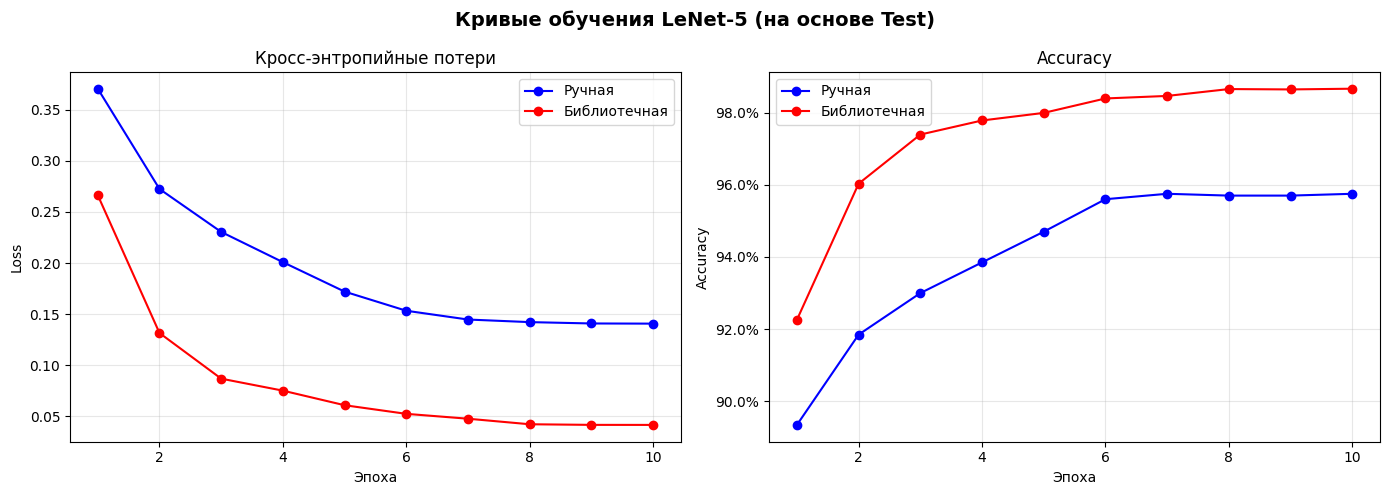

In [41]:
# Кривые обучения
ep_m = range(1, MANUAL_EPOCHS + 1)
ep_t = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Кривые обучения LeNet-5 (на основе Test)', fontsize=14, fontweight='bold')

ax1.plot(ep_m, hist_m['test_loss'],  'b-o', label='Ручная')
ax1.plot(ep_t, hist_t['test_loss'],  'r-o', label='Библиотечная')
ax1.set_title('Кросс-энтропийные потери')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep_m, hist_m['test_acc'],  'b-o', label='Ручная')
ax2.plot(ep_t, hist_t['test_acc'],  'r-o', label='Библиотечная')
ax2.set_title('Accuracy')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend();
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

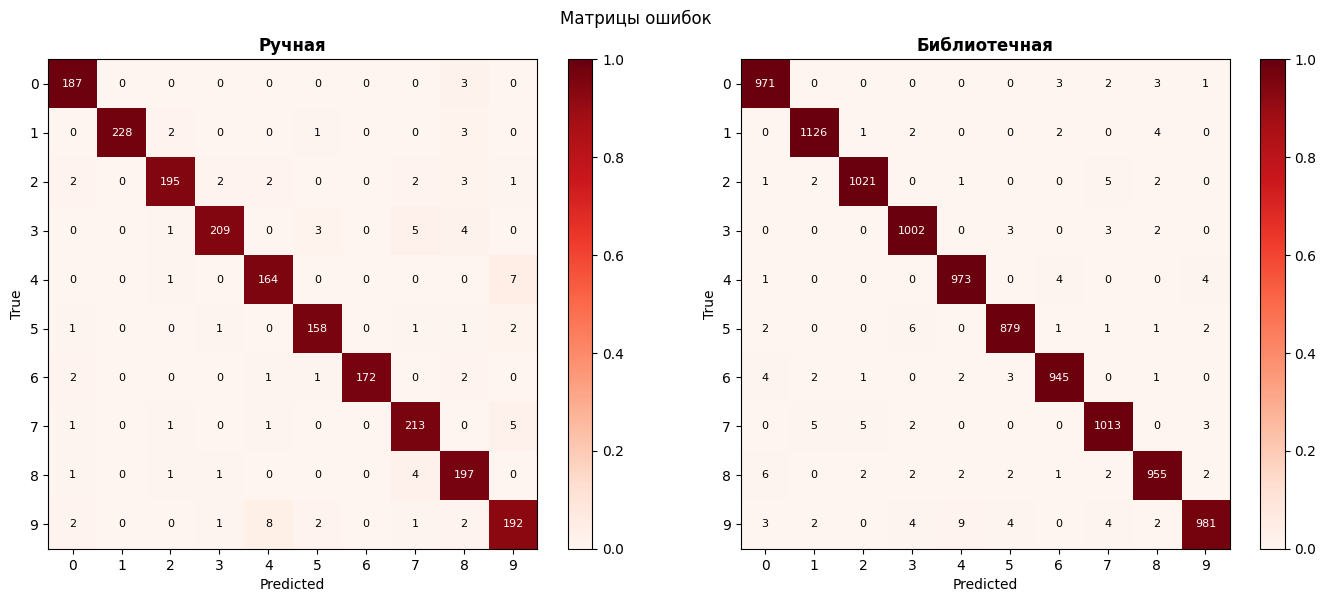

In [62]:
from collections import namedtuple
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(confusion_matrix, title, ax):
    n = confusion_matrix.shape[0]
    row_sums = confusion_matrix.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    norm = confusion_matrix.astype(float) / row_sums

    im = ax.imshow(norm, cmap='Reds', vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    for i in range(n):
        for j in range(n):
          ax.text(j, i, str(confusion_matrix[i, j]),
                  ha='center', va='center',
                  fontsize=8 if n <= 10 else 6,
                  color='white' if norm[i,j] > 0.5 else 'black')
    return im

fig, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(14, 6))

def calc_confusion_matrix(y_true, y_pred, n=10):
    return confusion_matrix(y_true, y_pred, labels=list(range(n)))

# Ручная
manual_preds = np.concatenate([
    manual_model.predict(X_te[i:i+MANUAL_BATCH])
    for i in range(0, len(X_te), MANUAL_BATCH)
])
manual_confusion = calc_confusion_matrix(y_te, manual_preds)

# Библиотечная
torch_model.eval()
torch_preds = np.concatenate([
    torch_model(xb.to(device)).argmax(1).cpu().numpy()
    for xb, _ in test_loader
])
torch_confusion = calc_confusion_matrix(y_test, torch_preds)

# График
fig.suptitle('Матрицы ошибок')
image_torch = plot_confusion_matrix(manual_confusion, 'Ручная', ax_1)
image_manual = plot_confusion_matrix(torch_confusion, 'Библиотечная', ax_2)
plt.colorbar(image_torch, ax=ax_1, fraction=0.05, pad=0.05)
plt.colorbar(image_manual, ax=ax_2, fraction=0.05, pad=0.05)
plt.tight_layout()
plt.show()